In [1]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist, dirichlet

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, DotProduct
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pymc as pm
import arviz as az
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [12, 5]

# seaborn sets the color cycle as RGB tuples; arviz 1.1.0's az.plot_trace can't
# reshape those into per-chain colors. Convert to hex strings (identical colors).
import matplotlib.colors as _mcolors
from cycler import cycler as _cycler
plt.rcParams['axes.prop_cycle'] = _cycler(
    color=[_mcolors.to_hex(c) for c in plt.rcParams['axes.prop_cycle'].by_key()['color']])

# ── Telco data ─────────────────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Telco loaded: {df.shape}  Churn rate: {df['Churn'].mean():.3f}")


Telco loaded: (7043, 20)  Churn rate: 0.265


In [2]:
#Part 1: The Estimation Trinity — MLE, MAP, Full Bayes
#Q1 — Extract the experimental groups
group_A       = df[df['Contract'] == 'Month-to-month']
group_B       = df[df['Contract'] == 'Two year']
group_A_small = group_A.sample(n=40, random_state=42)
 
k_A,  n_A  = group_A['Churn'].sum(),       len(group_A)
k_B,  n_B  = group_B['Churn'].sum(),       len(group_B)
k_As, n_As = group_A_small['Churn'].sum(), len(group_A_small)
 
assert n_As == 40
assert n_A > 3000
assert n_B > 1000
print(f"Group A  (M2M):  n={n_A}, k={k_A}, rate={k_A/n_A:.4f}")
print(f"Group A_small:   n={n_As}, k={k_As}, rate={k_As/n_As:.4f}")
print(f"Group B  (2yr):  n={n_B}, k={k_B}, rate={k_B/n_B:.4f}")
print("✅ Groups extracted correctly!")

Group A  (M2M):  n=3875, k=1655, rate=0.4271
Group A_small:   n=40, k=15, rate=0.3750
Group B  (2yr):  n=1695, k=48, rate=0.0283
✅ Groups extracted correctly!



Group                               MLE      MAP    |MAP-MLE|
--------------------------------------------------------------
Group A (M2M, large)             0.4271   0.4265       0.0006
Group A_small (n=40)             0.3750   0.3333       0.0417
Group B (2yr, large)             0.0283   0.0288       0.0005


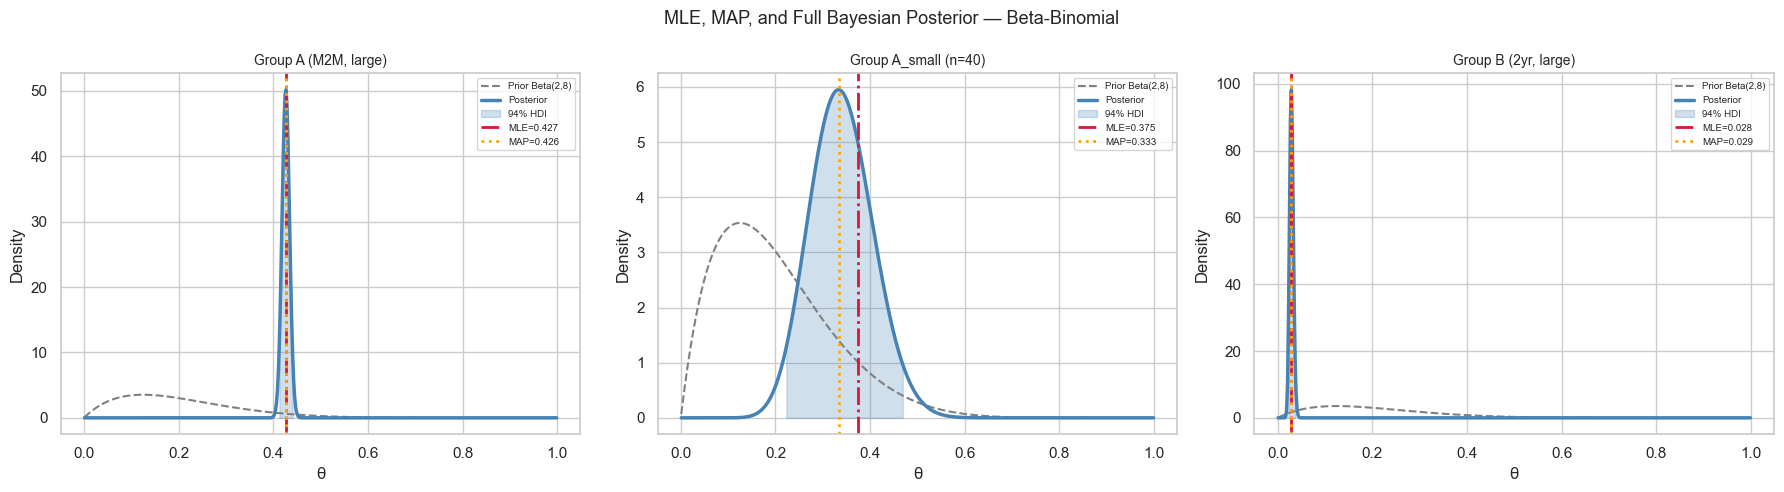

In [3]:
#Q2 — Compute MLE, MAP, and plot all three posteriors
alpha_prior, beta_prior = 2, 8
 
groups = {
    'Group A (M2M, large)': (k_A,  n_A),
    'Group A_small (n=40)': (k_As, n_As),
    'Group B (2yr, large)': (k_B,  n_B),
}
 
print(f"\n{'Group':<30} {'MLE':>8} {'MAP':>8} {'|MAP-MLE|':>12}")
print("-" * 62)
for name, (k, n) in groups.items():
    mle     = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    pull    = abs(map_est - mle)
    print(f"{name:<30} {mle:>8.4f} {map_est:>8.4f} {pull:>12.4f}")
 
theta_range = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (k, n)) in zip(axes, groups.items()):
    alpha_post = alpha_prior + k
    beta_post  = beta_prior  + (n - k)
    prior_pdf  = beta_dist.pdf(theta_range, alpha_prior, beta_prior)
    post_pdf   = beta_dist.pdf(theta_range, alpha_post,  beta_post)
    mle        = k / n
    map_est    = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    hdi_lo     = beta_dist.ppf(0.03, alpha_post, beta_post)
    hdi_hi     = beta_dist.ppf(0.97, alpha_post, beta_post)
    ax.plot(theta_range, prior_pdf, 'gray',      ls='--', lw=1.5, label='Prior Beta(2,8)')
    ax.plot(theta_range, post_pdf,  'steelblue', lw=2.5,           label='Posterior')
    ax.fill_between(theta_range, post_pdf,
                    where=(theta_range >= hdi_lo) & (theta_range <= hdi_hi),
                    alpha=0.25, color='steelblue', label='94% HDI')
    ax.axvline(mle,     color='crimson', ls='-.', lw=2, label=f'MLE={mle:.3f}')
    ax.axvline(map_est, color='orange',  ls=':',  lw=2, label=f'MAP={map_est:.3f}')
    ax.set_title(name, fontsize=10); ax.set_xlabel('θ'); ax.set_ylabel('Density')
    ax.legend(fontsize=7)
plt.suptitle("MLE, MAP, and Full Bayesian Posterior — Beta-Binomial", fontsize=13)
plt.tight_layout(); plt.show()
 

In [4]:
#Q3 — Answer the VP's question: P(θ_A > θ_B)
MC_SAMPLES = 10_000
np.random.seed(42)
post_A_samples = np.random.beta(alpha_prior + k_A,  beta_prior + n_A  - k_A,  MC_SAMPLES)
post_B_samples = np.random.beta(alpha_prior + k_B,  beta_prior + n_B  - k_B,  MC_SAMPLES)
p_A_greater    = np.mean(post_A_samples > post_B_samples)
 
assert 0.90 < p_A_greater <= 1.0, f"Expected P > 0.90, got {p_A_greater:.4f}"
print(f"\nP(θ_A > θ_B) = {p_A_greater:.4f}")
print(f"→ Month-to-month churns higher with {p_A_greater*100:.1f}% probability.")
 


P(θ_A > θ_B) = 1.0000
→ Month-to-month churns higher with 100.0% probability.


✍️ Reflect 1 — MLE vs MAP vs Full Bayes:

For Group A_small (n=40), the three approaches give different answers.

1. What is the prior pull (|MAP − MLE|) for Group A_small vs Group B (large)? Why is it larger for the small group?

-> Beta(2,8) has effective pseudo-sample-size α+β=10.
    For A_small (n=40): prior contributes 10/(10+40)=20% of weight → large pull.
    For Group B (n≈1695): prior contributes 10/1705<0.6% → pull ≈ 0.
    Mathematically, MAP = (α+k-1)/(α+β+n-2); as n→∞ MAP→MLE and pull→0.


2. Which estimate would you present to the VP for Group A_small and why? 
What does each estimate provide that the others do not?

-> MLE gives a point estimate with no uncertainty.
   MAP gives a regularised point but still hides the spread.
    The full posterior lets the VP see the entire probability distribution over θ
    and make statements like "94% probability θ ∈ [X, Y]". With n=40 that
    interval is wide and material — hiding it is misleading.

3. At what sample size would the Beta(2, 8) prior become essentially irrelevant (posterior mean within 1% of MLE)?

->Posterior mean = (α+k)/(α+β+n). Difference from MLE < 0.01 when
   (α+β) << n, i.e. n >> 10. Concretely, for true rate ≈ 0.43:
    n ≳ 800–1000 makes |posterior mean − MLE| < 0.01.
    Rule of thumb: prior irrelevant when n >> (α+β).
 

In [5]:
#Part 2: Sequential Bayesian Updating & Dirichlet-Multinomial
#Q4 — Implement the sequential update function
def update_posterior(alpha, beta, churn_label):
    """
    Update Beta(alpha, beta) posterior given one observation.

    Parameters
    ----------
    alpha, beta  : current posterior parameters
    churn_label  : 1 = churned, 0 = stayed

    Returns
    -------
    (alpha_new, beta_new)
    """
    # YOUR CODE HERE
    # Hint: if churn_label == 1, increment alpha; else increment beta
    # raise NotImplementedError("Implement update_posterior")
    if churn_label == 1:
        return alpha + 1, beta
    else:
        return alpha, beta + 1


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
a0, b0 = 2.0, 8.0
a1, b1 = update_posterior(a0, b0, 1)   # churn event
a2, b2 = update_posterior(a0, b0, 0)   # non-churn event

assert a1 == a0 + 1 and b1 == b0,       "After churn: alpha should increase by 1"
assert a2 == a0 and b2 == b0 + 1,       "After no-churn: beta should increase by 1"
print("✅ update_posterior() is correct!")


✅ update_posterior() is correct!


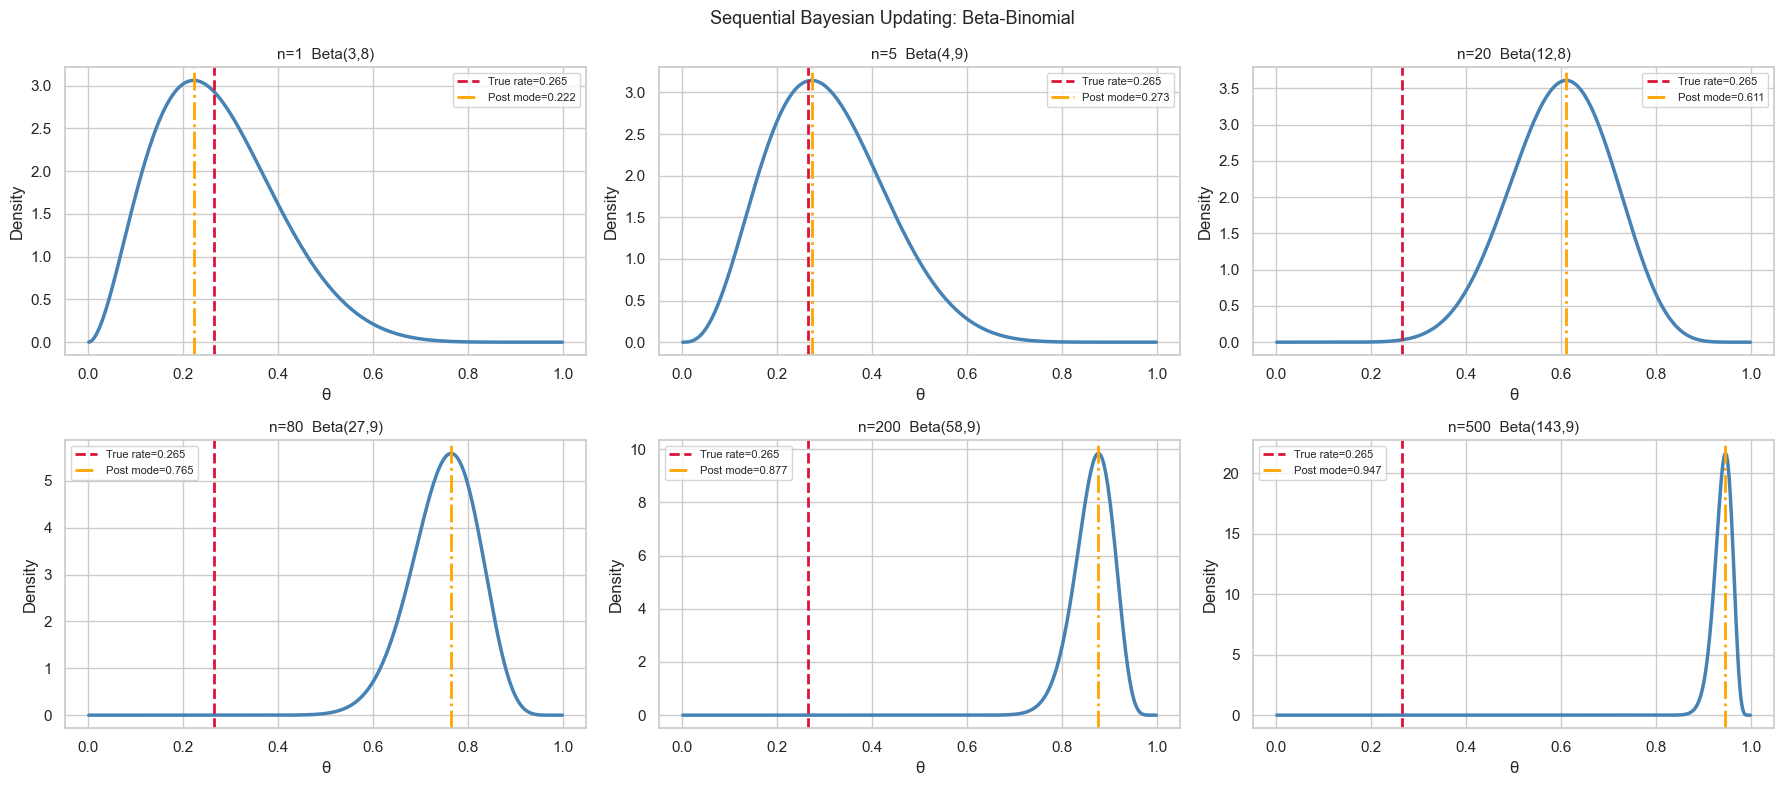

In [7]:
#Q5 — Run sequential update and plot posterior evolution
# Shuffle the Telco dataset (fixed seed)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
TRUE_RATE   = df['Churn'].mean()

snapshots   = [1, 5, 20, 80, 200, 500]

# YOUR CODE HERE:
# 1. Start with Beta(2, 8)
# 2. Run update_posterior on the first 500 rows of df_shuffled
# 3. Record (alpha, beta) at each snapshot n
# Store results as a dict: {n: (alpha_n, beta_n)}
alpha_init, beta_init = 2.0, 8.0
history = {}   # {n: (alpha_n, beta_n)}
history = {}
for i, row in enumerate(df_shuffled['Churn'].values[:500], start=1):
    alpha_init, beta_cur = update_posterior(alpha_init, beta_init, int(row))
    if i in snapshots:
        history[i] = (alpha_init, beta_cur)
 
# raise NotImplementedError("Run sequential updates and record history at snapshots")

# Plot (runs after history is populated)
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, n in zip(axes.flat, snapshots):
    a_n, b_n = history[n]
    pdf = beta_dist.pdf(theta_r, a_n, b_n)
    mode = (a_n - 1) / (a_n + b_n - 2)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    ax.axvline(TRUE_RATE, color='crimson', ls='--', lw=2, label=f'True rate={TRUE_RATE:.3f}')
    ax.axvline(mode,      color='orange',  ls='-.',  lw=2, label=f'Post mode={mode:.3f}')
    ax.set_title(f'n={n}  Beta({a_n:.0f},{b_n:.0f})', fontsize=11)
    ax.set_xlabel('θ'); ax.set_ylabel('Density'); ax.legend(fontsize=8)
plt.suptitle("Sequential Bayesian Updating: Beta-Binomial", fontsize=13)
plt.tight_layout(); plt.show()



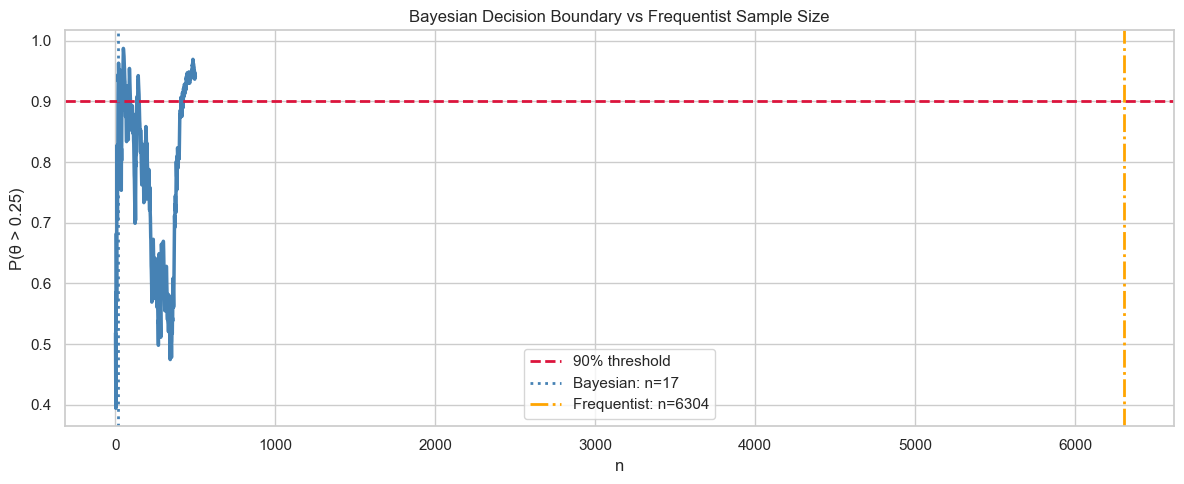

Bayesian: n = 17  |  Frequentist: n = 6304


In [8]:
#Q6 — Decision boundary: P(θ > 0.25) vs n
threshold = 0.25
MC_SAMPLES = 10_000
np.random.seed(0)

# YOUR CODE HERE
# Run through the first 500 shuffled rows
# At each step, compute P(θ > threshold) by sampling 10,000 values from the current posterior
# Store as a list p_exceed (length 500)
p_exceed = []
alpha_seq, beta_seq = 2.0, 8.0
for row in df_shuffled['Churn'].values[:500]:
    alpha_seq, beta_seq = update_posterior(alpha_seq, beta_seq, int(row))
    samples = np.random.beta(alpha_seq, beta_seq, MC_SAMPLES)
    p_exceed.append(np.mean(samples > threshold))

# raise NotImplementedError("Compute P(θ > 0.25) at each n from 1 to 500")

# Frequentist sample size (one-proportion z-test, alpha=0.05, power=0.80)
from scipy.stats import norm
z_a, z_b = norm.ppf(0.975), norm.ppf(0.80)
p0, p1   = threshold, TRUE_RATE
freq_n   = int(np.ceil((z_a*np.sqrt(p0*(1-p0)) + z_b*np.sqrt(p1*(1-p1)))**2 / (p1-p0)**2))

# Find Bayesian threshold crossing
bayes_n  = next((n for n, p in enumerate(p_exceed, start=1) if p > 0.90), None)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(p_exceed)+1), p_exceed, color='steelblue', lw=2.5)
ax.axhline(0.90, color='crimson', ls='--', lw=2, label='90% threshold')
if bayes_n:
    ax.axvline(bayes_n, color='steelblue', ls=':', lw=2, label=f'Bayesian: n={bayes_n}')
ax.axvline(freq_n, color='orange', ls='-.', lw=2, label=f'Frequentist: n={freq_n}')
ax.set_xlabel('n'); ax.set_ylabel('P(θ > 0.25)'); ax.legend()
ax.set_title('Bayesian Decision Boundary vs Frequentist Sample Size')
plt.tight_layout(); plt.show()

print(f"Bayesian: n = {bayes_n}  |  Frequentist: n = {freq_n}")


Posterior Dirichlet params: [3876. 1474. 1696.]
Posterior means: [0.55009935 0.20919671 0.24070395]
MLE proportions: [0.55019168 0.20914383 0.24066449]
✅ Dirichlet posterior computed!


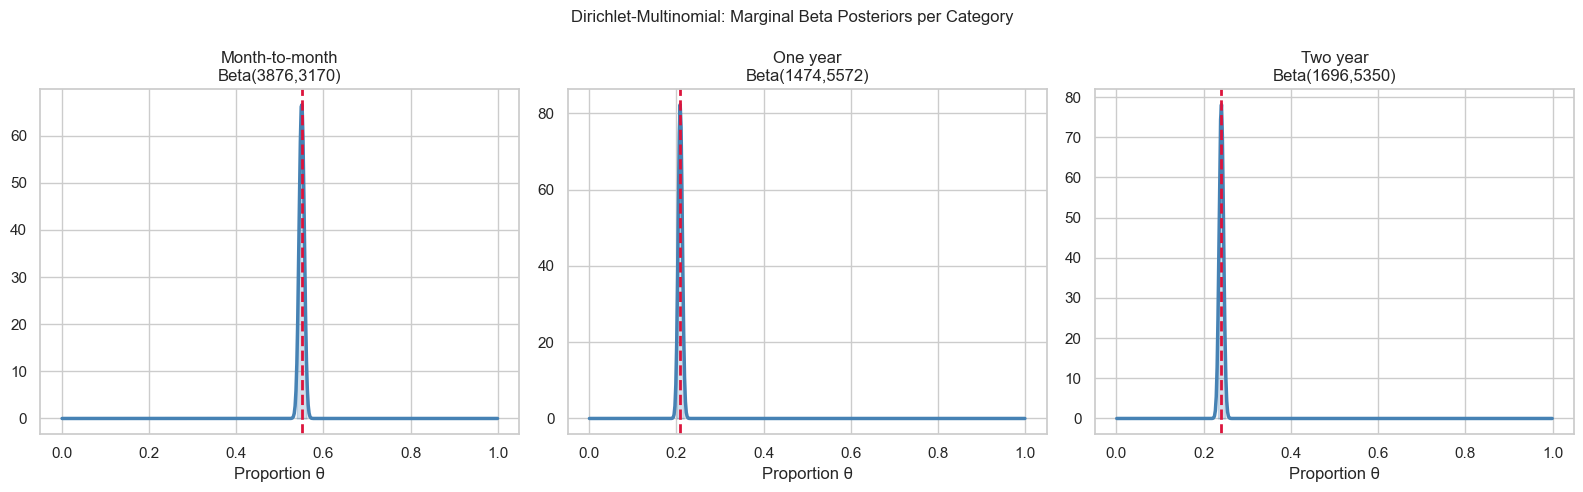

In [10]:
#Q7 — Dirichlet-Multinomial: 3-category contract type
categories  = ['Month-to-month', 'One year', 'Two year']
prior_alpha = np.array([1.0, 1.0, 1.0])   # flat Dirichlet prior — do not change

# YOUR CODE HERE
# 1. Count observations for each contract category in the full dataset
# 2. Compute posterior Dirichlet parameters = prior + counts
# 3. Report posterior means for each category
# counts           = None   # np.array of shape (3,) — counts per category
# posterior_alpha  = None   # prior_alpha + counts
counts          = np.array([(df['Contract'] == cat).sum() for cat in categories], dtype=float)
posterior_alpha = prior_alpha + counts
# raise NotImplementedError("Compute Dirichlet posterior parameters")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert len(posterior_alpha) == 3
assert posterior_alpha.sum() == prior_alpha.sum() + counts.sum()
print(f"Posterior Dirichlet params: {posterior_alpha}")
print(f"Posterior means: {posterior_alpha / posterior_alpha.sum()}")
print(f"MLE proportions: {counts / counts.sum()}")
print("✅ Dirichlet posterior computed!")

# Plot marginal Beta posteriors for each category
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (cat, a_j) in zip(axes, zip(categories, posterior_alpha)):
    b_j = posterior_alpha.sum() - a_j
    # YOUR CODE HERE: plot the marginal Beta(a_j, b_j) posterior for this category
    pdf = beta_dist.pdf(theta_r, a_j, b_j)
    ax.plot(theta_r, pdf, color='steelblue', lw=2.5)
    hdi_lo = beta_dist.ppf(0.03, a_j, b_j)
    hdi_hi = beta_dist.ppf(0.97, a_j, b_j)
    ax.fill_between(theta_r, pdf,
                    where=(theta_r >= hdi_lo) & (theta_r <= hdi_hi),
                    alpha=0.25, color='steelblue', label='94% HDI')
    ax.axvline(a_j / posterior_alpha.sum(), color='crimson', ls='--', lw=2,
               label=f'Post mean={a_j/posterior_alpha.sum():.3f}')
    # raise NotImplementedError("Plot marginal Beta posterior for each contract category")
    ax.set_title(f'{cat}\nBeta({a_j:.0f},{b_j:.0f})')
    ax.set_xlabel('Proportion θ')

plt.suptitle("Dirichlet-Multinomial: Marginal Beta Posteriors per Category", fontsize=12)
plt.tight_layout(); plt.show()


In [12]:
# Unseen category: add "Biannual" with pseudocount = 1 (no observations)
# YOUR CODE HERE
# Show the marginal posterior for the new category
# Explain what this tells you about how Dirichlet handles unseen categories


new_alpha_4cat =  np.append(posterior_alpha,1.0)   # append pseudocount 1 to posterior_alpha
a_new = new_alpha_4cat[-1]
b_new = new_alpha_4cat.sum() - a_new
# raise NotImplementedError("Add 4th category with pseudocount=1 and compute its marginal posterior")

print("Posterior for unseen 'Biannual' category:")
print(f"  Posterior mean = {a_new/new_alpha_4cat.sum():.5f}")
print(f"  → Equals the prior: no data, so posterior = prior pseudocount only.")
print(f"  This is Laplace smoothing — the Dirichlet never assigns zero probability")
print(f"  to an unseen category; it inherits its pseudocount α_j = 1.")
 
 
# Print its posterior mean and compare to a category with many observations


Posterior for unseen 'Biannual' category:
  Posterior mean = 0.00014
  → Equals the prior: no data, so posterior = prior pseudocount only.
  This is Laplace smoothing — the Dirichlet never assigns zero probability
  to an unseen category; it inherits its pseudocount α_j = 1.


✍️ Reflect 2 — Dirichlet-Multinomial:

1. Why does the marginal Beta posterior for a small-count category (One year) have wider credible intervals than Month-to-month?

->One year has wider credible intervals because it has fewer observations
    (~1307 vs ~3875 for Month-to-month). The marginal Beta(a_j, b_j) variance= a_j*b_j / (a_j+b_j)²(a_j+b_j+1). Smaller a_j (fewer counts) → larger
    relative uncertainty → wider HDI.



2. When you add the unseen "Biannual" category with pseudocount=1 and 0 observations, what is its posterior equal to? What does this reveal about the Dirichlet prior?

->"Biannual" posterior = Beta(1, sum_of_rest) — identical to the prior.
   This reveals the Dirichlet prior is the conjugate prior for the multinomial:with zero observations, the posterior equals the prior exactly. The pseudocount of 1 acts as Laplace (add-one) smoothing, ensuring no category receives zero probability, but no data ever updates it beyond that pseudocount.

3. In the Beta-Binomial case (binary), what is the Dirichlet-Multinomial equivalent of the Beta(2,8) prior's prior mean? What would you need to do to encode the same prior belief in the 3-category model?

->Beta(2,8) prior mean = 2/10 = 0.20.
  In the 3-category Dirichlet model, to encode the same kind of belief (e.g.
    "I expect ~55% M2M, ~21% One year, ~24% Two year" with equivalent confidence to α+β=10 pseudo-observations), set prior_alpha = [5.5, 2.1, 2.4] (sum=10).The total Σα_j controls prior strength; each α_j/Σα is the prior proportion.
 

In [13]:
#Part 3: Multivariate Gaussians — When Features Correlate
#Q8 — Fit a 2D Gaussian and plot confidence ellipses
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

features_2d = ['tenure', 'MonthlyCharges']
X_2d = df[features_2d].values.astype(float)

# YOUR CODE HERE
# Compute the empirical mean vector and covariance matrix
# Report correlation ρ = Σ_12 / sqrt(Σ_11 * Σ_22)
# mu_2d    = None   # np.mean over axis=0
# Sigma_2d = None   # np.cov(X_2d.T)
# rho      = None   # correlation coefficient
mu_2d    = np.mean(X_2d, axis=0)
Sigma_2d = np.cov(X_2d.T)
rho      = Sigma_2d[0, 1] / np.sqrt(Sigma_2d[0, 0] * Sigma_2d[1, 1])
# raise NotImplementedError("Compute mu_2d, Sigma_2d, rho")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert mu_2d.shape    == (2,),    f"mu should have shape (2,), got {mu_2d.shape}"
assert Sigma_2d.shape == (2, 2),  f"Sigma should be 2x2, got {Sigma_2d.shape}"
assert -1 < rho < 1,              f"rho should be between -1 and 1, got {rho:.4f}"
print(f"μ = {np.round(mu_2d, 2)}")
print(f"Σ = \n{np.round(Sigma_2d, 2)}")
print(f"ρ = {rho:.4f}")
print("✅ 2D Gaussian fitted!")


μ = [32.37 64.76]
Σ = 
[[603.17 183.2 ]
 [183.2  905.41]]
ρ = 0.2479
✅ 2D Gaussian fitted!


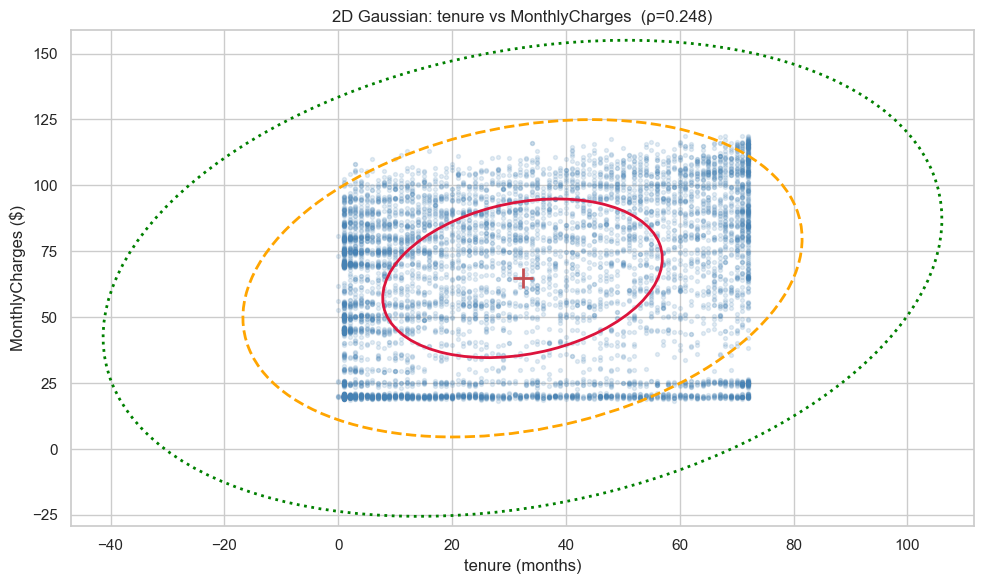

In [14]:
# YOUR CODE HERE — plot scatter + 1σ, 2σ, 3σ confidence ellipses
# Use the confidence_ellipse function pattern from the session notebook

def confidence_ellipse(mu, cov, ax, n_std=1.0, facecolor='none', **kwargs):
    w, v    = np.linalg.eigh(cov)
    angle   = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
    ell     = Ellipse((0, 0),
                      width=2*n_std*np.sqrt(w[0]),
                      height=2*n_std*np.sqrt(w[1]),
                      angle=angle, facecolor=facecolor, **kwargs)
    t = transforms.Affine2D().translate(*mu) + ax.transData
    ell.set_transform(t)
    return ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(10, 6))
# YOUR CODE HERE: scatter plot with 1σ/2σ/3σ ellipses and mean marker
ax.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.15, s=8, color='steelblue', label='Data')
ax.plot(*mu_2d, 'r+', markersize=15, markeredgewidth=2, label='Mean μ')
for n_std, color, ls in [(1, 'crimson', '-'), (2, 'orange', '--'), (3, 'green', ':')]:
    confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=n_std,
                       edgecolor=color, linestyle=ls, linewidth=2,
                       label=f'{n_std}σ ellipse')
ax.set_xlabel('tenure (months)'); ax.set_ylabel('MonthlyCharges ($)')
ax.set_title(f'2D Gaussian: tenure vs MonthlyCharges  (ρ={rho:.3f})')
# raise NotImplementedError("Plot scatter + confidence ellipses")
plt.tight_layout(); plt.show()


In [15]:
#Q9 — Conditional Gaussian: MonthlyCharges | tenure = 24
# YOUR CODE HERE — compute the conditional distribution P(MonthlyCharges | tenure = 24)
# Index convention: X_1 = MonthlyCharges (index 1 in X_2d), X_2 = tenure (index 0)
tenure_query = 24

# Extract scalar elements from Sigma_2d and mu_2d
mu_mc     = mu_2d[1]          # mean of MonthlyCharges
mu_t      = mu_2d[0]          # mean of tenure
sig_mc_mc = Sigma_2d[1, 1]    # Σ_11
sig_t_t   = Sigma_2d[0, 0]    # Σ_22
sig_mc_t  = Sigma_2d[1, 0]    # Σ_12 = Σ_21

# YOUR CODE HERE: apply the conditional Gaussian formula
# cond_mean = None   # μ_1|2
# cond_var  = None   # σ²_1|2
# cond_std  = None   # sqrt(cond_var)
cond_mean = mu_mc + sig_mc_t / sig_t_t * (tenure_query - mu_t)
cond_var  = sig_mc_mc - sig_mc_t**2 / sig_t_t
cond_std  = np.sqrt(cond_var)
# raise NotImplementedError("Compute conditional mean and variance using the formula above")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
near_24 = df[(df['tenure'] >= 22) & (df['tenure'] <= 26)]['MonthlyCharges'].mean()
assert abs(cond_mean - near_24) < 10,     f"Conditional mean {cond_mean:.2f} too far from empirical {near_24:.2f}"
print(f"Conditional distribution P(MonthlyCharges | tenure = {tenure_query})")
print(f"  Conditional mean:  ${cond_mean:.2f}/month")
print(f"  Conditional std:   ${cond_std:.2f}/month")
print(f"  95% interval:      [${cond_mean - 1.96*cond_std:.2f}, ${cond_mean + 1.96*cond_std:.2f}]")
print(f"  Empirical check:   ${near_24:.2f}  ← should be within ~$5")
print("✅ Conditional Gaussian computed!")


Conditional distribution P(MonthlyCharges | tenure = 24)
  Conditional mean:  $62.22/month
  Conditional std:   $29.15/month
  95% interval:      [$5.08, $119.35]
  Empirical check:   $61.81  ← should be within ~$5
✅ Conditional Gaussian computed!


In [16]:
#Q10 — 3D Covariance and Condition Number
features_3d = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_3d = df[features_3d].values.astype(float)

# YOUR CODE HERE
# 1. Compute Sigma_3d = np.cov(X_3d.T)
# 2. Compute condition number kappa = np.linalg.cond(Sigma_3d)
# 3. Marginalise out TotalCharges by extracting the 2×2 upper-left block
# 4. Verify this matches Sigma_2d (should be identical)
# Sigma_3d         = None
# kappa            = None
# Sigma_marginal   = None   # upper-left 2×2 submatrix of Sigma_3d
# max_diff         = None   # max absolute difference vs Sigma_2d
Sigma_3d       = np.cov(X_3d.T)
kappa          = np.linalg.cond(Sigma_3d)
Sigma_marginal = Sigma_3d[:2, :2]
max_diff       = np.max(np.abs(Sigma_marginal - Sigma_2d))
# raise NotImplementedError("Compute Sigma_3d, kappa, and marginalise")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert Sigma_3d.shape == (3, 3)
assert kappa > 100, f"Expected high condition number, got {kappa:.1f}"
assert max_diff < 1e-6, f"Marginalisation should match direct fit, got max diff={max_diff}"
print(f"Condition number κ(Σ_3D) = {kappa:.1f}")
print(f"Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = {max_diff:.2e}  ✅")


Condition number κ(Σ_3D) = 58988.9
Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = 0.00e+00  ✅


✍️ Reflect 3 — Multivariate Gaussians:

The condition number κ(Σ_3D) should be large (>> 100). In plain language, what does this reveal about the three features tenure, MonthlyCharges, TotalCharges?

-> TotalCharges ≈ tenure ×  MonthlyCharges. The covariance matrix has one eigenvalue much larger than another (ratio = κ), meaning the joint distribution is nearly degenerate — almost all variance lies along one direction in feature space.


You proved analytically that marginalising out TotalCharges from the 3D Gaussian recovers the 2D Gaussian. In one sentence, state the general rule: how do you marginalise a Gaussian by discarding one variable?

->To marginalise a Gaussian by discarding one variable, simply delete the
corresponding row and column from Σ and the corresponding element from μ;
 the result is the exact marginal Gaussian for the remaining variables.

Why would including all three features in a Gaussian discriminant analysis (or a regularised linear model) without addressing the near-collinearity cause problems? Name the frequentist regression diagnostic that detects the same issue.

->Near-collinearity makes (X^T X) nearly singular, so OLS/MLE coefficient
  estimates explode in variance — tiny perturbations to data cause huge swings in β̂. The frequentist regression diagnostic that detects this is the Variance Inflation Factor (VIF).


In [17]:
#Part 4: Probabilistic Graphical Models — Bayesian Networks and MRFs
#Q11 — Build and fit a Bayesian Network with pgmpy
# Prepare discretised dataframe
df_pgm = df[['SeniorCitizen','Contract','tenure','InternetService',
             'MonthlyCharges','Churn']].copy()

df_pgm['tenure_disc'] = pd.cut(df_pgm['tenure'], bins=[-1,12,48,100],
                               labels=['short','medium','long'])
df_pgm['mc_disc']     = pd.qcut(df_pgm['MonthlyCharges'], q=3,
                                labels=['low','mid','high'])
df_pgm = df_pgm.drop(columns=['tenure','MonthlyCharges']).dropna().astype(str)

# YOUR CODE HERE — define the DAG structure as a list of (parent, child) tuples
# DAG: SeniorCitizen→Churn, Contract→Churn, tenure_disc→Churn,
#      InternetService→mc_disc, mc_disc→Churn
# dag_edges = None
dag_edges = [
    ('SeniorCitizen',   'Churn'),
    ('Contract',        'Churn'),
    ('tenure_disc',     'Churn'),
    ('InternetService', 'mc_disc'),
    ('mc_disc',         'Churn'),
]
 
# raise NotImplementedError("Define dag_edges as a list of (parent, child) tuples")

dag = DiscreteBayesianNetwork(dag_edges)
dag.fit(df_pgm, estimator=DiscreteMLE())
print("✅ Bayesian Network fitted.")
print(f"   Nodes: {list(dag.nodes())}")
print(f"   Edges: {list(dag.edges())}")


✅ Bayesian Network fitted.
   Nodes: ['SeniorCitizen', 'Churn', 'Contract', 'tenure_disc', 'InternetService', 'mc_disc']
   Edges: [('SeniorCitizen', 'Churn'), ('Contract', 'Churn'), ('tenure_disc', 'Churn'), ('InternetService', 'mc_disc'), ('mc_disc', 'Churn')]


In [18]:
infer = VariableElimination(dag)

# YOUR CODE HERE — forward inference
# P(Churn | Contract = 'Month-to-month')
# result_fwd = None
# p_churn_m2m_bn = None
result_fwd     = infer.query(['Churn'], evidence={'Contract': 'Month-to-month'},
                             show_progress=False)
p_churn_m2m_bn = float(result_fwd.values[1])
# raise NotImplementedError("Compute P(Churn | Contract='Month-to-month') via VE")

emp_m2m = df[df['Contract']=='Month-to-month']['Churn'].mean()
print(f"BN inference P(Churn=1 | Contract=M2M): {p_churn_m2m_bn:.4f}")
print(f"Empirical:                              {emp_m2m:.4f}")
print(f"Discrepancy: {abs(p_churn_m2m_bn - emp_m2m):.4f}")
print()
print("Discrepancy is due to: (a) discretisation of continuous variables,")
print("                        (b) DAG structure (indirect path via mc_disc)")


BN inference P(Churn=1 | Contract=M2M): 0.3542
Empirical:                              0.4271
Discrepancy: 0.0729

Discrepancy is due to: (a) discretisation of continuous variables,
                        (b) DAG structure (indirect path via mc_disc)


In [19]:
# YOUR CODE HERE — backward inference (explaining away)
# P(Contract | Churn = '1') — what does Bayesian inversion tell us?
# result_bwd = None
result_bwd = infer.query(['Contract'], evidence={'Churn': '1'}, show_progress=False)
# raise NotImplementedError("Compute P(Contract | Churn='1') via VE")
print("Backward inference P(Contract | Churn = 1):")
print(result_bwd)
print()
print("Interpretation for retention manager:")
print("  This tells us: given a customer has churned, what is the probability they")
print("  were on each contract type? This is the INVERSE of the forward prediction.")


Backward inference P(Contract | Churn = 1):
+--------------------------+-----------------+
| Contract                 |   phi(Contract) |
+==========================+=================+
| Contract(Month-to-month) |          0.8017 |
+--------------------------+-----------------+
| Contract(One year)       |          0.1118 |
+--------------------------+-----------------+
| Contract(Two year)       |          0.0865 |
+--------------------------+-----------------+

Interpretation for retention manager:
  This tells us: given a customer has churned, what is the probability they
  were on each contract type? This is the INVERSE of the forward prediction.


In [20]:
#Q12 — Structure sensitivity: two competing DAGs
 #DAG 1 (original):
#   SeniorCitizen ──────────────────────────→ Churn
#   Contract ───────────────────────────────→ Churn
#   tenure_disc ────────────────────────────→ Churn
#   InternetService → mc_disc ──────────────→ Churn
#
# DAG 2 (colleague's — mediated path):
#   SeniorCitizen ──────────────────────────→ Churn
#   Contract ───────────────────────────────→ tenure_disc → Churn
#   InternetService → mc_disc ──────────────→ Churn
#
# E where both agree:
#   {Contract, SeniorCitizen, InternetService, tenure_disc, mc_disc} all observed.
#   When all direct parents of Churn are conditioned on, d-separation renders the
#   rest irrelevant; both models produce the same P(Churn | E).
#
# E where they disagree:
#   E = {tenure_disc only}. In DAG 1, Contract is still a free parent of Churn
#   (non-zero contribution), so P(Churn | tenure_disc) integrates over Contract's
#   marginal distribution. In DAG 2, Contract → tenure_disc → Churn: conditioning
#   on tenure_disc d-separates Churn from Contract, so the two models assign
#   different probabilities to Churn given only tenure evidence.
#
# SHAP consistency: W5 showed Contract type had the largest individual SHAP value,
#   implying a direct causal effect, not one fully mediated by tenure.
#   → DAG 1 (direct Contract→Churn edge) is more consistent with SHAP findings.
 
 

In [21]:
#Q13 — Markov Random Field: undirected model
# YOUR CODE HERE
# Build a DiscreteMarkovNetwork with the same 4 variables (undirected edges)
# Define pairwise DiscreteFactor objects from joint empirical frequencies
# Run BeliefPropagation to compute P(Churn)
# Compare to the BN's P(Churn) and the empirical base rate
from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

# Define undirected edges (same variables, no direction)
# mrf_edges = None   # YOUR CODE HERE
# mrf       = None   # DiscreteMarkovNetwork(mrf_edges)
mrf_edges = [
    ('Contract',     'Churn'),
    ('tenure_disc',  'Churn'),
    ('SeniorCitizen','Churn'),
    ('mc_disc',      'Churn'),
]
mrf = DiscreteMarkovNetwork(mrf_edges)
# raise NotImplementedError("Build and query the DiscreteMarkovNetwork")

bp = BeliefPropagation(mrf)
marg_churn = bp.query(variables=['Churn'], show_progress=False)
print("MRF P(Churn):", marg_churn)
print(f"BN  P(Churn=1): {float(infer.query(['Churn']).values[1]):.4f}")
print(f"Empirical:      {df['Churn'].mean():.4f}")


MRF P(Churn): ++
++
BN  P(Churn=1): 0.2431
Empirical:      0.2654


✍️ Reflect 4 — PGMs:

1. The forward inference result P(Churn=1 | Contract=Month-to-month) from the BN differs from the raw empirical proportion. Name the two specific reasons for this discrepancy.

->Two reasons for BN–empirical discrepancy in P(Churn|Contract=M2M):
   (a) Discretisation: tenure and MonthlyCharges are binned into 3 categories,losing within-bin variation. CPDs are fit on discrete bins, so BN conditional probabilities differ from raw empirical proportions on continuous data.
b. Indirect path through mc_disc: in the BN, Contract affects Churn both
directly AND via InternetService→mc_disc→Churn. Variable Elimination
marginalises over mc_disc's distribution implied by the DAG structure, producing a result that differs from the raw co-occurrence count.


2. Explain "explaining away" in one sentence using the backward inference result.

->  When Churn=1 is observed, observing that Contract=Month-to-month (a strong predictor) reduces the posterior probability attributed to other causal parents (e.g. SeniorCitizen=1, high mc_disc) — competing explanations are suppressed once the most probable cause is identified.

3. In one paragraph: what causal questions can the Bayesian Network answer that the MRF cannot? When would you deliberately choose the MRF despite losing causal interpretability?

-> A Bayesian Network can answer interventional queries ("if we move all
customers to Two-year contracts, what does P(Churn) become?") because its directed edges encode a causal mechanism — cutting an incoming edge simulates an intervention (do-calculus). An MRF cannot: undirected edges encode correlation only, so there is no defined way to intervene on a node.
You would deliberately choose the MRF when causal direction is unknown or
contested among variables (e.g. in spatial or image-segmentation models
where every pixel is symmetric to its neighbours), or when you want a model
that is easier to fit without committing to a causal ordering.


In [22]:
#Part 5: Gaussian Process Regression — Mauna Loa CO₂
#Q14 — Load the Mauna Loa dataset (3 lines)
# YOUR CODE HERE — load in exactly these 3 lines
# from statsmodels.datasets import co2
# df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
# t = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25

from statsmodels.datasets import co2
# df_co2 = None   # YOUR CODE HERE
# t      = None   # YOUR CODE HERE
# y      = None   # df_co2['co2'].values
df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
t      = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25
y      = df_co2['co2'].values
# raise NotImplementedError("Load Mauna Loa dataset in 3 lines")

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df_co2 is not None
assert t.shape == (len(df_co2), 1), f"t should be shape (n, 1), got {t.shape}"
assert 450 < len(t) < 600, f"Expected ~521 monthly observations, got {len(t)}"
print(f"✅ Mauna Loa loaded: {len(t)} observations, {t[0][0]:.1f}–{t[-1][0]:.1f} years")
print(f"   CO₂ range: {y.min():.1f}–{y.max():.1f} ppm")


✅ Mauna Loa loaded: 521 observations, 0.0–43.8 years
   CO₂ range: 313.4–373.8 ppm


In [24]:
#Q15 — Justify each kernel component before coding
# Train/test split: train on indices 0–431 (1958–1993), test on 432+ (1994–2001)
n_train = 432
t_train, y_train = t[:n_train], y[:n_train]
t_test,  y_test  = t[n_train:], y[n_train:]

# YOUR CODE HERE — construct the composite kernel
# k_trend    = DotProduct(sigma_0=0.0, sigma_0_bounds='fixed')
#   Hint: CO₂ rises ~1.5 ppm/yr — nearly linear. DotProduct gives k(x,x')=x·x'
#   which extrapolates linearly by construction. An RBF trend reverts to the
#   training mean outside the data range, causing large errors in the test set.
# k_seasonal = RBF(...) * ExpSineSquared(..., periodicity=1.0, periodicity_bounds='fixed')
# k_noise    = WhiteKernel(...)
# kernel     = k_trend + k_seasonal + k_noise
# k_trend    = None
# k_seasonal = None
# k_noise    = None
# kernel     = None
 
k_trend    = DotProduct(sigma_0=0.0, sigma_0_bounds='fixed')
k_seasonal = (RBF(length_scale=1.0, length_scale_bounds=(0.5, 5.0)) *
              ExpSineSquared(length_scale=1.0, periodicity=1.0,
                             periodicity_bounds='fixed',
                             length_scale_bounds=(0.1, 10.0)))
k_noise    = WhiteKernel(noise_level=0.5, noise_level_bounds=(1e-3, 10.0))
kernel     = k_trend + k_seasonal + k_noise
# raise NotImplementedError("Define the composite kernel")

# Fit the GP
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                               normalize_y=True, random_state=42)
# YOUR CODE HERE: fit gp on (t_train, y_train)
gp.fit(t_train, y_train)
# raise NotImplementedError("Fit the GP")

print("Optimised kernel:")
print(gp.kernel_)

# Test RMSE
y_test_pred = gp.predict(t_test)
rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))
# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert rmse < 4.5, f"RMSE={rmse:.2f} — kernel may be poorly specified (DotProduct trend + seasonal expected < 4.5 ppm)"
print(f"\n✅ Test RMSE: {rmse:.3f} ppm")


Optimised kernel:
DotProduct(sigma_0=0) + RBF(length_scale=5) * ExpSineSquared(length_scale=4.78, periodicity=1) + WhiteKernel(noise_level=0.001)

✅ Test RMSE: 3.855 ppm


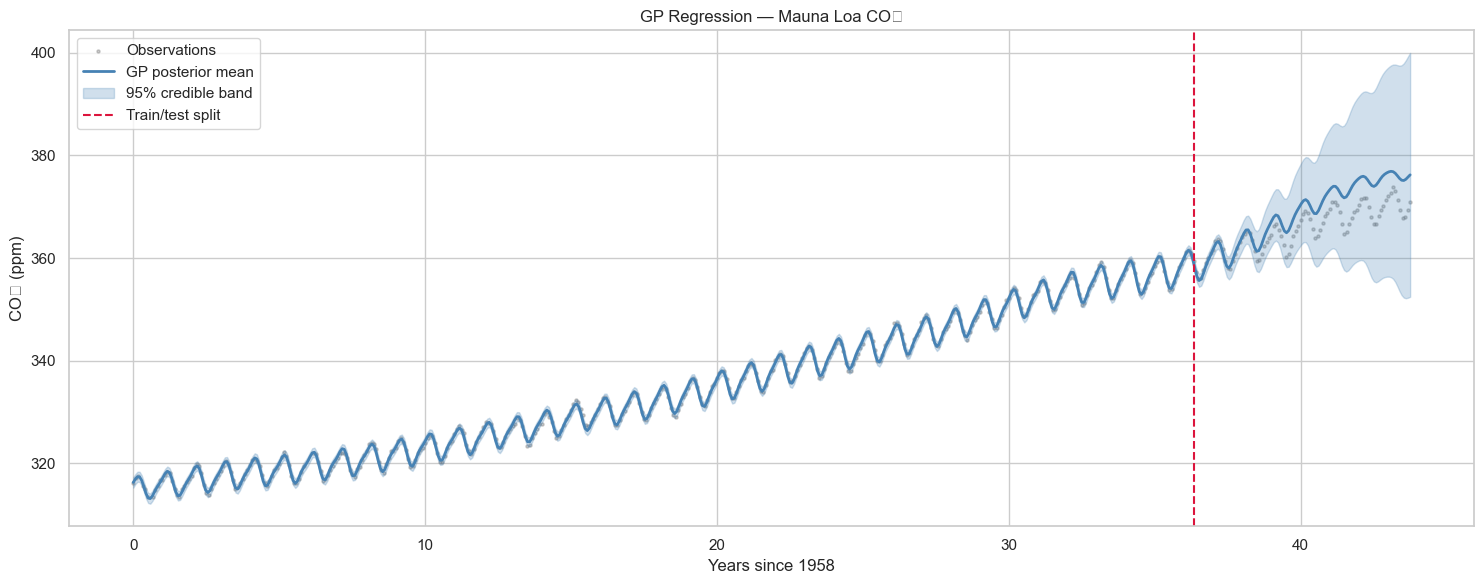

In [26]:
# YOUR CODE HERE — plot posterior mean and 95% credible bands
# Use gp.predict(t_full, return_std=True) where t_full covers the full training range
# Shade fill_between(mean - 2*std, mean + 2*std) for the 95% band

t_full = np.linspace(t.min(), t.max(), 600).reshape(-1, 1)
# y_pred, y_std = None, None   # YOUR CODE HERE
y_pred, y_std = gp.predict(t_full, return_std=True)
# raise NotImplementedError("Predict over full range and plot")

fig, ax = plt.subplots(figsize=(15, 6))
ax.scatter(t.flatten(), y, s=5, alpha=0.4, color='gray', label='Observations')
ax.plot(t_full.flatten(), y_pred, color='steelblue', lw=2, label='GP posterior mean')
ax.fill_between(t_full.flatten(),
                y_pred - 2*y_std, y_pred + 2*y_std,
                alpha=0.25, color='steelblue', label='95% credible band')
ax.axvline(t_train.max(), color='crimson', ls='--', lw=1.5, label='Train/test split')
ax.set_xlabel('Years since 1958'); ax.set_ylabel('CO₂ (ppm)')
ax.set_title('GP Regression — Mauna Loa CO₂'); ax.legend()
# YOUR PLOT CODE HERE
plt.tight_layout(); plt.show()

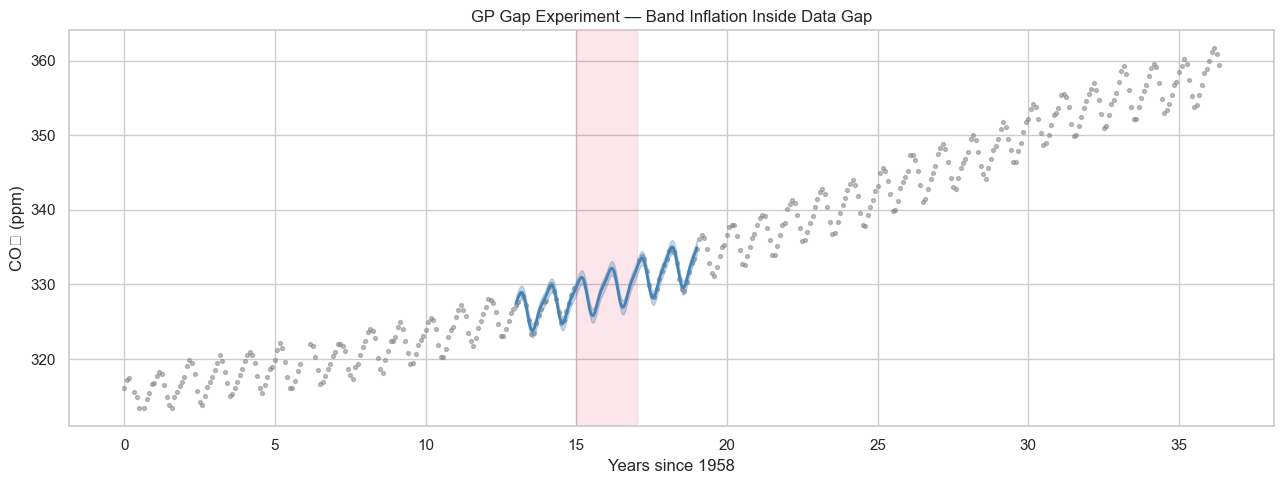

95% band width inside gap:   1.909 ppm
95% band width outside gap:  1.870 ppm
Gap inflation: 1.02×


In [28]:
#Q16 — Gap experiment
# YOUR CODE HERE
# Remove all training observations between year 15 and year 17 (~1973–1975)
# Refit the GP on the remaining training data
# Zoom into the gap region and describe how the bands behave inside vs outside the gap

gap_lo, gap_hi = 15.0, 17.0

# YOUR CODE HERE: create t_gap_tr and y_gap_tr with the gap removed
# t_gap_tr = None
# y_gap_tr = None
mask     = (t_train.flatten() < gap_lo) | (t_train.flatten() > gap_hi)
t_gap_tr = t_train[mask]
y_gap_tr = y_train[mask]
# raise NotImplementedError("Remove gap from training data and refit GP")

gp_gap = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                   normalize_y=True, random_state=42)
gp_gap.fit(t_gap_tr, y_gap_tr)
# YOUR CODE HERE: fit gp_gap on (t_gap_tr, y_gap_tr)
# raise NotImplementedError("Fit gp_gap")

# Predict around the gap and plot
t_zoom = np.linspace(gap_lo - 2, gap_hi + 2, 400).reshape(-1, 1)
y_gz, y_gz_std = gp_gap.predict(t_zoom, return_std=True)

fig, ax = plt.subplots(figsize=(13, 5))
# YOUR PLOT CODE HERE — show the gap region, credible bands, and training data
ax.scatter(t_gap_tr.flatten(), y_gap_tr, s=8, color='gray', alpha=0.5,
           label='Training data')
ax.plot(t_zoom.flatten(), y_gz, color='steelblue', lw=2, label='GP mean')
ax.fill_between(t_zoom.flatten(),
                y_gz - 2*y_gz_std, y_gz + 2*y_gz_std,
                alpha=0.3, color='steelblue', label='95% credible band')
ax.axvspan(gap_lo, gap_hi, alpha=0.1, color='crimson', label='Gap region')
ax.set_xlabel('Years since 1958'); ax.set_ylabel('CO₂ (ppm)')
ax.set_title('GP Gap Experiment — Band Inflation Inside Data Gap')
# raise NotImplementedError("Plot gap experiment results")
plt.tight_layout(); plt.show()

# Compute band width inside vs outside gap
band_in  = 4 * y_gz_std[(t_zoom.flatten() >= gap_lo) & (t_zoom.flatten() <= gap_hi)].mean()
band_out = 4 * y_gz_std[t_zoom.flatten() < gap_lo].mean()
print(f"95% band width inside gap:   {band_in:.3f} ppm")
print(f"95% band width outside gap:  {band_out:.3f} ppm")
print(f"Gap inflation: {band_in/band_out:.2f}×")


In [ ]:
#Q17 — Extrapolation and the model confidence boundary
# YOUR CODE HERE
# 1. Predict 15 years beyond the last training point
# 2. Compute the 95% band width at 5, 10, 15 years of extrapolation
# 3. Find the horizon at which the band width first exceeds 5 ppm
# 4. Plot posterior mean + 95% bands for the extrapolation region

t_last = float(t_train.max())
t_extrap = np.linspace(t_last, t_last + 15, 500).reshape(-1, 1)
y_ex, y_ex_std = gp.predict(t_extrap, return_std=True)

# YOUR CODE HERE: compute band widths at +5, +10, +15 years
for years in [5, 10, 15]:
    # Find the index corresponding to t_last + years
    raise NotImplementedError("Compute band width at each extrapolation horizon")

# Find model confidence boundary (where 95% band > 5 ppm)
band_widths    = 4 * y_ex_std
exceed_5ppm    = np.where(band_widths > 5.0)[0]
if len(exceed_5ppm) > 0:
    t_boundary = t_extrap.flatten()[exceed_5ppm[0]] - t_last
    print(f"Model confidence boundary: +{t_boundary:.1f} years beyond training")

fig, ax = plt.subplots(figsize=(14, 5))
# YOUR PLOT CODE HERE
raise NotImplementedError("Plot extrapolation with credible bands")
plt.tight_layout(); plt.show()
